<a href="https://colab.research.google.com/github/vrundan7/carla-ml-safety/blob/main/temperature_scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/2026 (1)/2026"


import os
import csv
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

MODEL_DIR = f"{BASE_PATH}/model_outputs"
BATCH_SIZE = 32

# All test splits
TEST_SPLITS = {
    "test":         {"csv": f"{BASE_PATH}/test/test/labels.csv",
                     "img": f"{BASE_PATH}/test/test/rgb-front"},
    "test-fog":     {"csv": f"{BASE_PATH}/test-fog/test-fog/labels.csv",
                     "img": f"{BASE_PATH}/test-fog/test-fog/rgb-front"},
    "test-night":   {"csv": f"{BASE_PATH}/test-night/test-night/labels.csv",
                     "img": f"{BASE_PATH}/test-night/test-night/rgb-front"},
    "test-town-01": {"csv": f"{BASE_PATH}/test-town-01/test-town-01/labels.csv",
                     "img": f"{BASE_PATH}/test-town-01/test-town-01/rgb-front"},
}

print("Test splits found:")
for name, paths in TEST_SPLITS.items():
    exists = "✅" if os.path.exists(paths["csv"]) else "❌"
    print(f"  {exists} {name}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Test splits found:
  ✅ test
  ✅ test-fog
  ✅ test-night
  ✅ test-town-01


Dataset & Model

In [4]:
class DrivingDataset(Dataset):
    def __init__(self, csv_path, img_dir, label_col, transform=None):
        self.transform = transform
        self.samples = []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                frame = row['frame']
                label = 1.0 if row[label_col] == 'True' else 0.0
                img_path = os.path.join(img_dir, f"{frame}.jpg")
                if os.path.exists(img_path):
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Load pedestrian model
model = models.resnet18(weights=None)
model.fc = nn.Linear(512, 1)
model.load_state_dict(torch.load(
    os.path.join(MODEL_DIR, "best_has_pedestrian.pth"), map_location=DEVICE))
model.to(DEVICE).eval()

print(f"✅ Pedestrian model loaded.")



✅ Pedestrian model loaded.


Collect raw logits from ALL test splits

In [5]:
nw = 2 if torch.cuda.is_available() else 0

split_data = {}  # {split_name: {'logits': np.array, 'labels': np.array}}

for split_name, paths in TEST_SPLITS.items():
    if not os.path.exists(paths["csv"]):
        print(f"⚠️  Skipping {split_name} — not found")
        continue

    ds = DrivingDataset(paths["csv"], paths["img"], 'has_pedestrian', test_transform)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=nw, pin_memory=torch.cuda.is_available())

    logits_list, labels_list = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs).squeeze()
            logits_list.extend(logits.cpu().numpy())
            labels_list.extend(lbls.numpy())

    split_data[split_name] = {
        'logits': np.array(logits_list),
        'labels': np.array(labels_list),
    }
    print(f"  {split_name}: {len(logits_list)} samples, "
          f"{int(sum(labels_list))} positive, "
          f"logits [{min(logits_list):.2f}, {max(logits_list):.2f}]")

# Also combine all splits into one
all_logits = np.concatenate([d['logits'] for d in split_data.values()])
all_labels = np.concatenate([d['labels'] for d in split_data.values()])
print(f"\n  TOTAL: {len(all_logits)} samples, {int(all_labels.sum())} positive")



  test: 3600 samples, 706 positive, logits [-5.20, 4.54]
  test-fog: 3600 samples, 733 positive, logits [-3.91, 2.27]
  test-night: 3600 samples, 732 positive, logits [-2.93, 3.43]
  test-town-01: 3600 samples, 325 positive, logits [-5.54, 3.46]

  TOTAL: 14400 samples, 2496 positive


Temperature Scaling — Accuracy at T = 0.5, 1.0, 2.0

Per-split + overall

In [6]:

def apply_temperature(logits, T):
    """Apply temperature scaling: p_T = sigmoid(z / T)"""
    return 1.0 / (1.0 + np.exp(-logits / T))

temperatures = [0.5, 1.0, 2.0]
threshold = 0.5

# Store results for later plotting
temp_results_per_split = {}  # {split_name: {T: {'p_T', 'preds', 'acc'}}}
temp_results_all = {}        # {T: {'p_T', 'preds', 'acc'}} for combined data

# --- Per-split results ---
for split_name, data in split_data.items():
    print(f"\n{'='*70}")
    print(f"  {split_name} — Temperature Scaling Accuracy (threshold=0.5)")
    print(f"{'='*70}")
    print(f"{'T':<8} {'Accuracy':<12} {'Pred=1':<12} {'Avg p_T':<12} {'Std p_T':<12}")
    print("-"*70)

    temp_results_per_split[split_name] = {}
    for T in temperatures:
        p_T = apply_temperature(data['logits'], T)
        preds = (p_T > threshold).astype(float)
        acc = np.mean(preds == data['labels'])

        temp_results_per_split[split_name][T] = {'p_T': p_T, 'preds': preds, 'acc': acc}
        print(f"{T:<8} {acc:<12.4f} {int(preds.sum()):<12} {p_T.mean():<12.4f} {p_T.std():<12.4f}")

# --- Combined results ---
print(f"\n{'='*70}")
print(f"  ALL SPLITS COMBINED — Temperature Scaling Accuracy")
print(f"{'='*70}")
print(f"{'T':<8} {'Accuracy':<12} {'Pred=1':<12} {'Avg p_T':<12} {'Std p_T':<12}")
print("-"*70)

for T in temperatures:
    p_T = apply_temperature(all_logits, T)
    preds = (p_T > threshold).astype(float)
    acc = np.mean(preds == all_labels)

    temp_results_all[T] = {'p_T': p_T, 'preds': preds, 'acc': acc}
    print(f"{T:<8} {acc:<12.4f} {int(preds.sum()):<12} {p_T.mean():<12.4f} {p_T.std():<12.4f}")

print("="*70)




  test — Temperature Scaling Accuracy (threshold=0.5)
T        Accuracy     Pred=1       Avg p_T      Std p_T     
----------------------------------------------------------------------
0.5      0.6553       1313         0.3792       0.3561      
1.0      0.6553       1313         0.4056       0.2669      
2.0      0.6553       1313         0.4395       0.1688      

  test-fog — Temperature Scaling Accuracy (threshold=0.5)
T        Accuracy     Pred=1       Avg p_T      Std p_T     
----------------------------------------------------------------------
0.5      0.7378       541          0.2066       0.2393      
1.0      0.7378       541          0.2892       0.1758      
2.0      0.7378       541          0.3756       0.1089      

  test-night — Temperature Scaling Accuracy (threshold=0.5)
T        Accuracy     Pred=1       Avg p_T      Std p_T     
----------------------------------------------------------------------
0.5      0.6342       1257         0.4130       0.2757      
1.

Explanation:
  • T = 0.5 (low):  Logits are amplified (z/0.5 = 2z), pushing probabilities
    toward 0 or 1. The model becomes more "confident" — predictions are sharper.
    Accuracy may stay similar or slightly change depending on how well-calibrated
    the original logits are.

  • T = 1.0 (default): Standard sigmoid, no scaling. This is the baseline.

  • T = 2.0 (high): Logits are dampened (z/2.0), pulling probabilities toward 0.5.
    The model becomes less "confident" — predictions are softer/uncertain.
    With a fixed threshold of 0.5, predictions can flip, often reducing accuracy.


# Accuracy comparison bar chart (per split × per T)

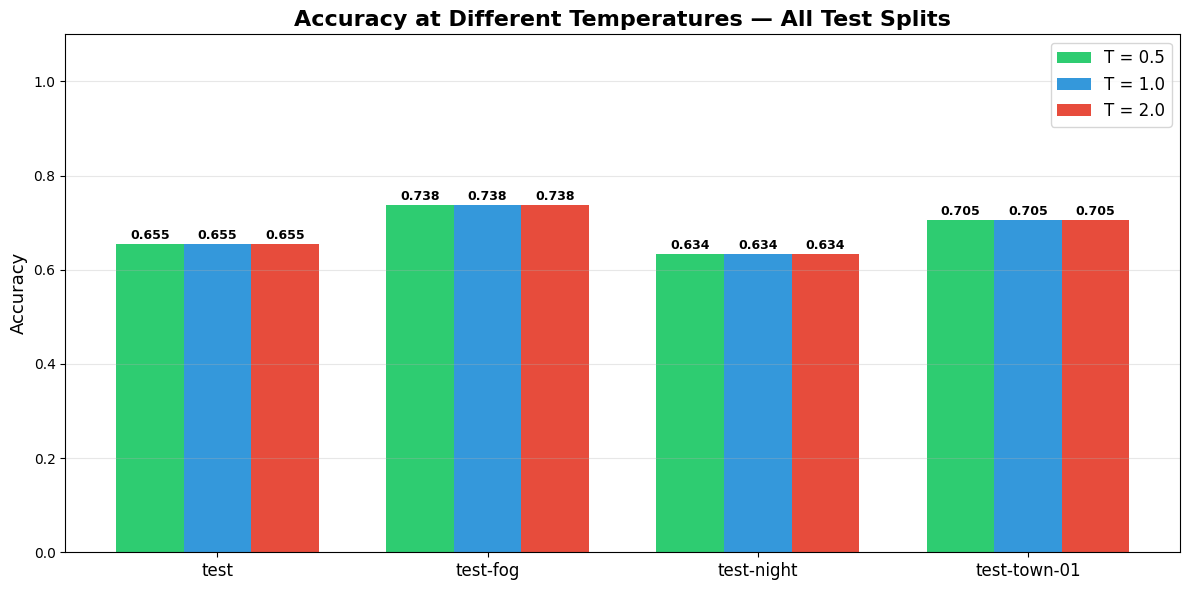

In [7]:

split_names = list(split_data.keys())
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(split_names))
width = 0.25
colors = ['#2ecc71', '#3498db', '#e74c3c']

for i, T in enumerate(temperatures):
    accs = [temp_results_per_split[s][T]['acc'] for s in split_names]
    bars = ax.bar(x + i * width, accs, width, label=f'T = {T}', color=colors[i])
    for bar, val in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Accuracy at Different Temperatures — All Test Splits', fontsize=16, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(split_names, fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/temp_accuracy_per_split.png", dpi=150, bbox_inches='tight')
plt.show()



Plot probability distributions for each T (all data combined)

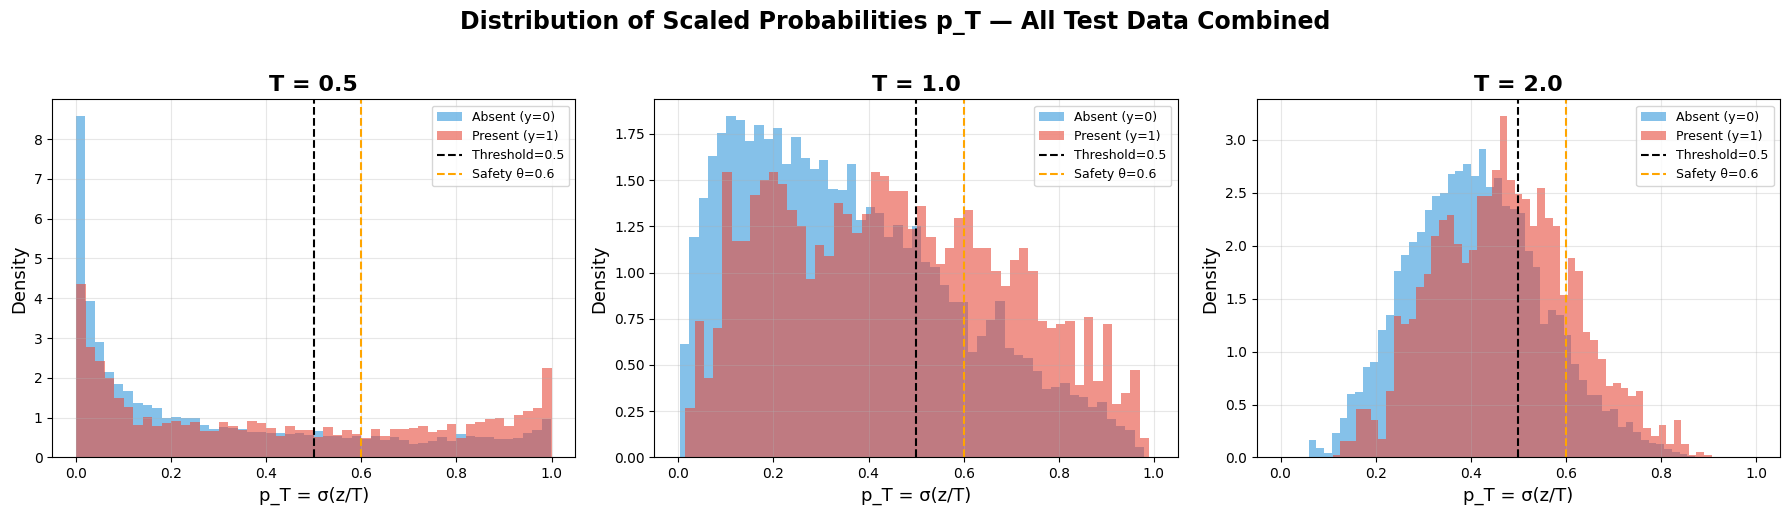

In [8]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, T in enumerate(temperatures):
    ax = axes[idx]
    p_T = temp_results_all[T]['p_T']

    p_pos = p_T[all_labels == 1]
    p_neg = p_T[all_labels == 0]

    ax.hist(p_neg, bins=50, alpha=0.6, color='#3498db', label='Absent (y=0)', density=True)
    ax.hist(p_pos, bins=50, alpha=0.6, color='#e74c3c', label='Present (y=1)', density=True)
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold=0.5')
    ax.axvline(x=0.6, color='orange', linestyle='--', linewidth=1.5, label='Safety θ=0.6')

    ax.set_title(f'T = {T}', fontsize=16, fontweight='bold')
    ax.set_xlabel('p_T = σ(z/T)', fontsize=13)
    ax.set_ylabel('Density', fontsize=13)
    ax.legend(fontsize=9)
    ax.set_xlim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of Scaled Probabilities p_T — All Test Data Combined',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/temp_scaling_distributions.png", dpi=150, bbox_inches='tight')
plt.show()



Distribution Shape Analysis:
  • T = 0.5: Bimodal — probabilities are pushed toward 0 and 1.
    Almost all predictions are very confident (near 0 or near 1).

  • T = 1.0: Moderate spread — the default sigmoid output.
    Some spread around the decision boundary but still reasonably separated.

  • T = 2.0: Unimodal / concentrated around 0.5 — probabilities are compressed
    toward the center. The two classes overlap significantly near 0.5.


# Per-split probability distributions

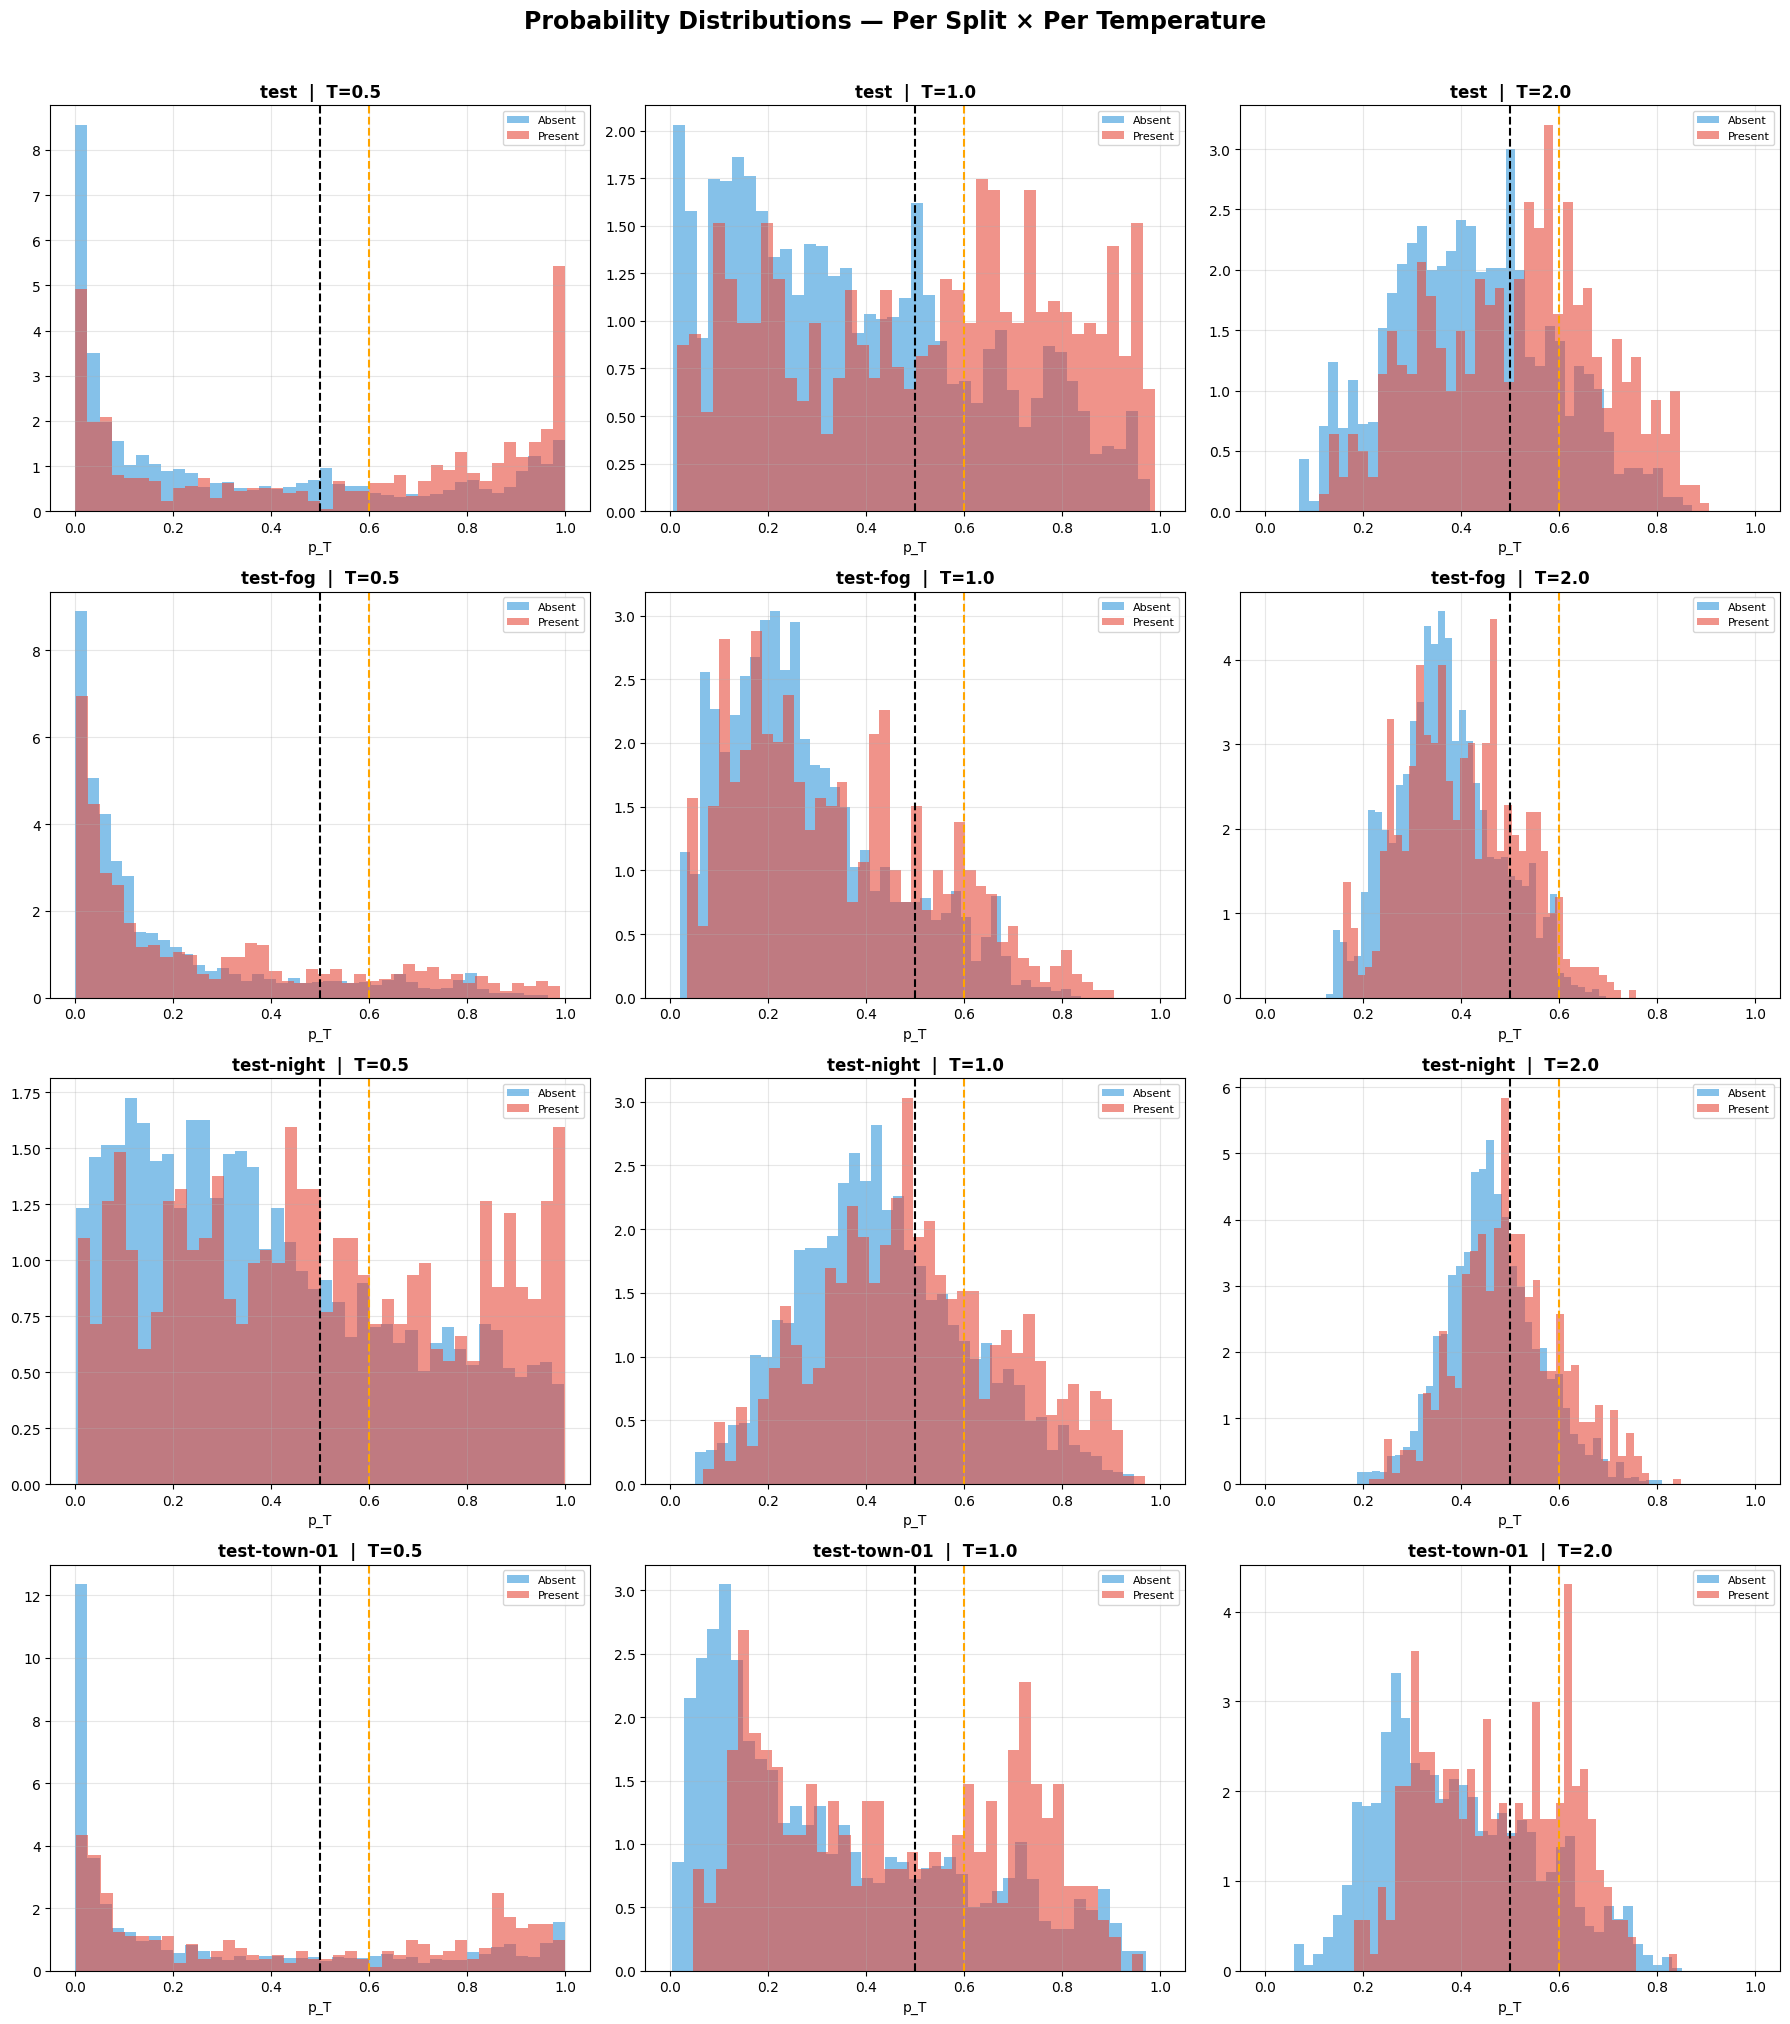

In [9]:

n_splits = len(split_names)
fig, axes = plt.subplots(n_splits, 3, figsize=(18, 5 * n_splits))
if n_splits == 1:
    axes = [axes]

for row, split_name in enumerate(split_names):
    data = split_data[split_name]
    for col, T in enumerate(temperatures):
        ax = axes[row][col]
        p_T = apply_temperature(data['logits'], T)

        p_pos = p_T[data['labels'] == 1]
        p_neg = p_T[data['labels'] == 0]

        ax.hist(p_neg, bins=40, alpha=0.6, color='#3498db', label='Absent', density=True)
        ax.hist(p_pos, bins=40, alpha=0.6, color='#e74c3c', label='Present', density=True)
        ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5)
        ax.axvline(x=0.6, color='orange', linestyle='--', linewidth=1.5)

        ax.set_title(f'{split_name}  |  T={T}', fontsize=12, fontweight='bold')
        ax.set_xlabel('p_T', fontsize=10)
        ax.set_xlim(-0.05, 1.05)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Probability Distributions — Per Split × Per Temperature',
             fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/temp_distributions_per_split.png", dpi=150, bbox_inches='tight')
plt.show()



Safety Constraint Analysis — θ = 0.6, per split

In [10]:

theta = 0.6

print("="*85)
print(f"  Safety Constraint: 'If confidence < θ={theta}, reduce speed to ≤ 15 km/h'")
print("="*85)
print(f"\n{'Split':<18} {'T':<8} {'% below θ':<15} {'# below θ':<15} {'Triggers':<15}")
print("-"*85)

for split_name, data in split_data.items():
    for T in temperatures:
        p_T = apply_temperature(data['logits'], T)
        confidence = np.maximum(p_T, 1 - p_T)
        below = np.mean(confidence < theta) * 100
        n_below = int(np.sum(confidence < theta))
        freq = 'Often' if below > 30 else 'Rarely' if below < 10 else 'Sometimes'
        print(f"{split_name:<18} {T:<8} {below:<15.1f} {n_below:<15} {freq:<15}")
    print()

print("="*85)



  Safety Constraint: 'If confidence < θ=0.6, reduce speed to ≤ 15 km/h'

Split              T        % below θ       # below θ       Triggers       
-------------------------------------------------------------------------------------
test               0.5      11.6            418             Sometimes      
test               1.0      20.4            735             Sometimes      
test               2.0      38.7            1394            Often          

test-fog           0.5      7.9             284             Rarely         
test-fog           1.0      17.7            637             Sometimes      
test-fog           2.0      36.0            1297            Often          

test-night         0.5      19.4            698             Sometimes      
test-night         1.0      37.5            1349            Often          
test-night         2.0      66.1            2381            Often          

test-town-01       0.5      8.2             294             Rarely         
te

Analysis — How T affects the safety constraint:

  • T = 0.5 (low temperature):
    The model is overconfident — nearly all predictions have confidence >> 0.6.
    The safety constraint RARELY triggers.
    ⚠️  THIS IS THE LEAST SAFE: the model appears confident even when wrong.
    False negatives (missed pedestrians) go undetected because the model
    says "I'm 99% sure there's no pedestrian" even when there is one.

  • T = 1.0 (default):
    Moderate confidence levels. The constraint triggers for genuinely
    uncertain predictions. This is the baseline behavior.

  • T = 2.0 (high temperature):
    The model is underconfident — many predictions have confidence near 0.5.
    The safety constraint triggers FREQUENTLY, causing constant speed reduction.
    This is overly conservative but safer — the system errs on the side of caution.

  KEY INSIGHT: T = 0.5 leads to the LEAST SAFE behavior because it suppresses
  the uncertainty signal that the safety constraint relies on.

  NOTE: Out-of-distribution splits (fog, night) may show different patterns
  since the model is inherently less certain on unseen conditions.


# Confidence Distribution Plot (all data combined)

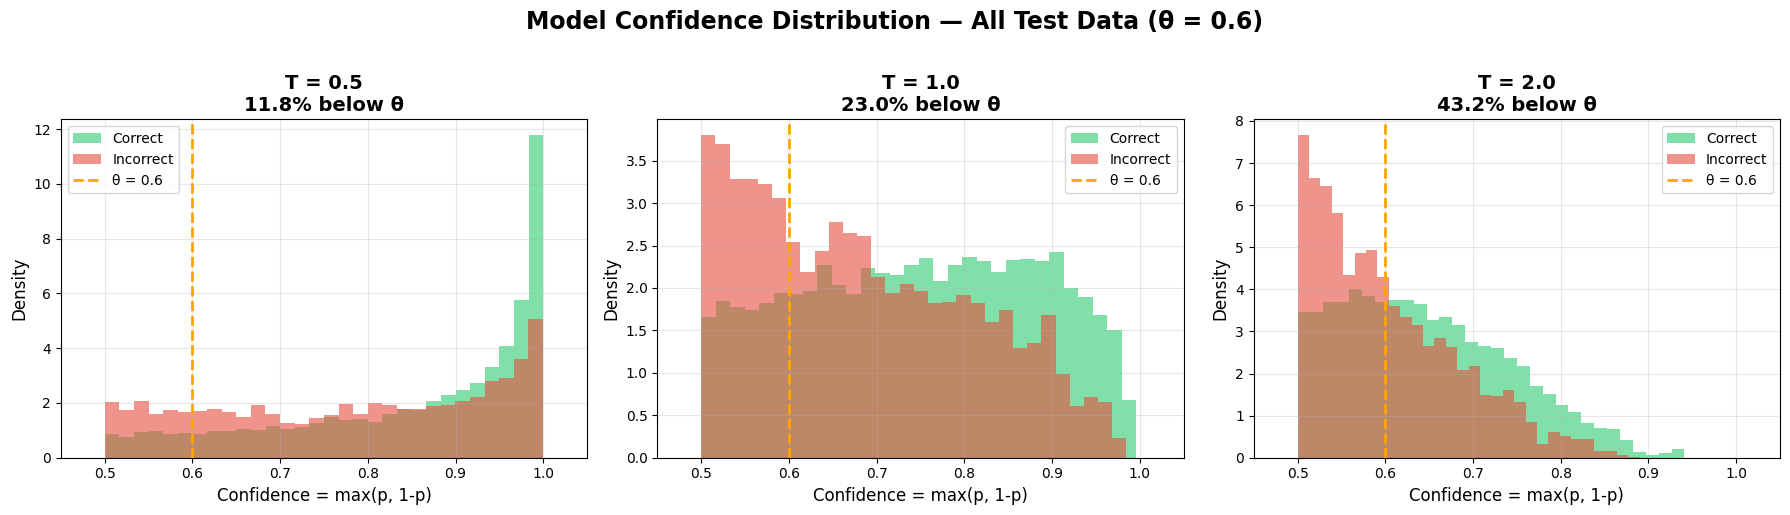

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, T in enumerate(temperatures):
    ax = axes[idx]
    p_T = temp_results_all[T]['p_T']
    confidence = np.maximum(p_T, 1 - p_T)

    preds = (p_T > 0.5).astype(float)
    correct = (preds == all_labels)

    ax.hist(confidence[correct], bins=30, alpha=0.6, color='#2ecc71',
            label='Correct', density=True)
    ax.hist(confidence[~correct], bins=30, alpha=0.6, color='#e74c3c',
            label='Incorrect', density=True)
    ax.axvline(x=theta, color='orange', linestyle='--', linewidth=2,
               label=f'θ = {theta}')

    below_pct = np.mean(confidence < theta) * 100
    ax.set_title(f'T = {T}\n{below_pct:.1f}% below θ', fontsize=14, fontweight='bold')
    ax.set_xlabel('Confidence = max(p, 1-p)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_xlim(0.45, 1.05)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Model Confidence Distribution — All Test Data (θ = {theta})',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/confidence_distributions.png", dpi=150, bbox_inches='tight')
plt.show()



Reliability Diagrams (calibration) — per split

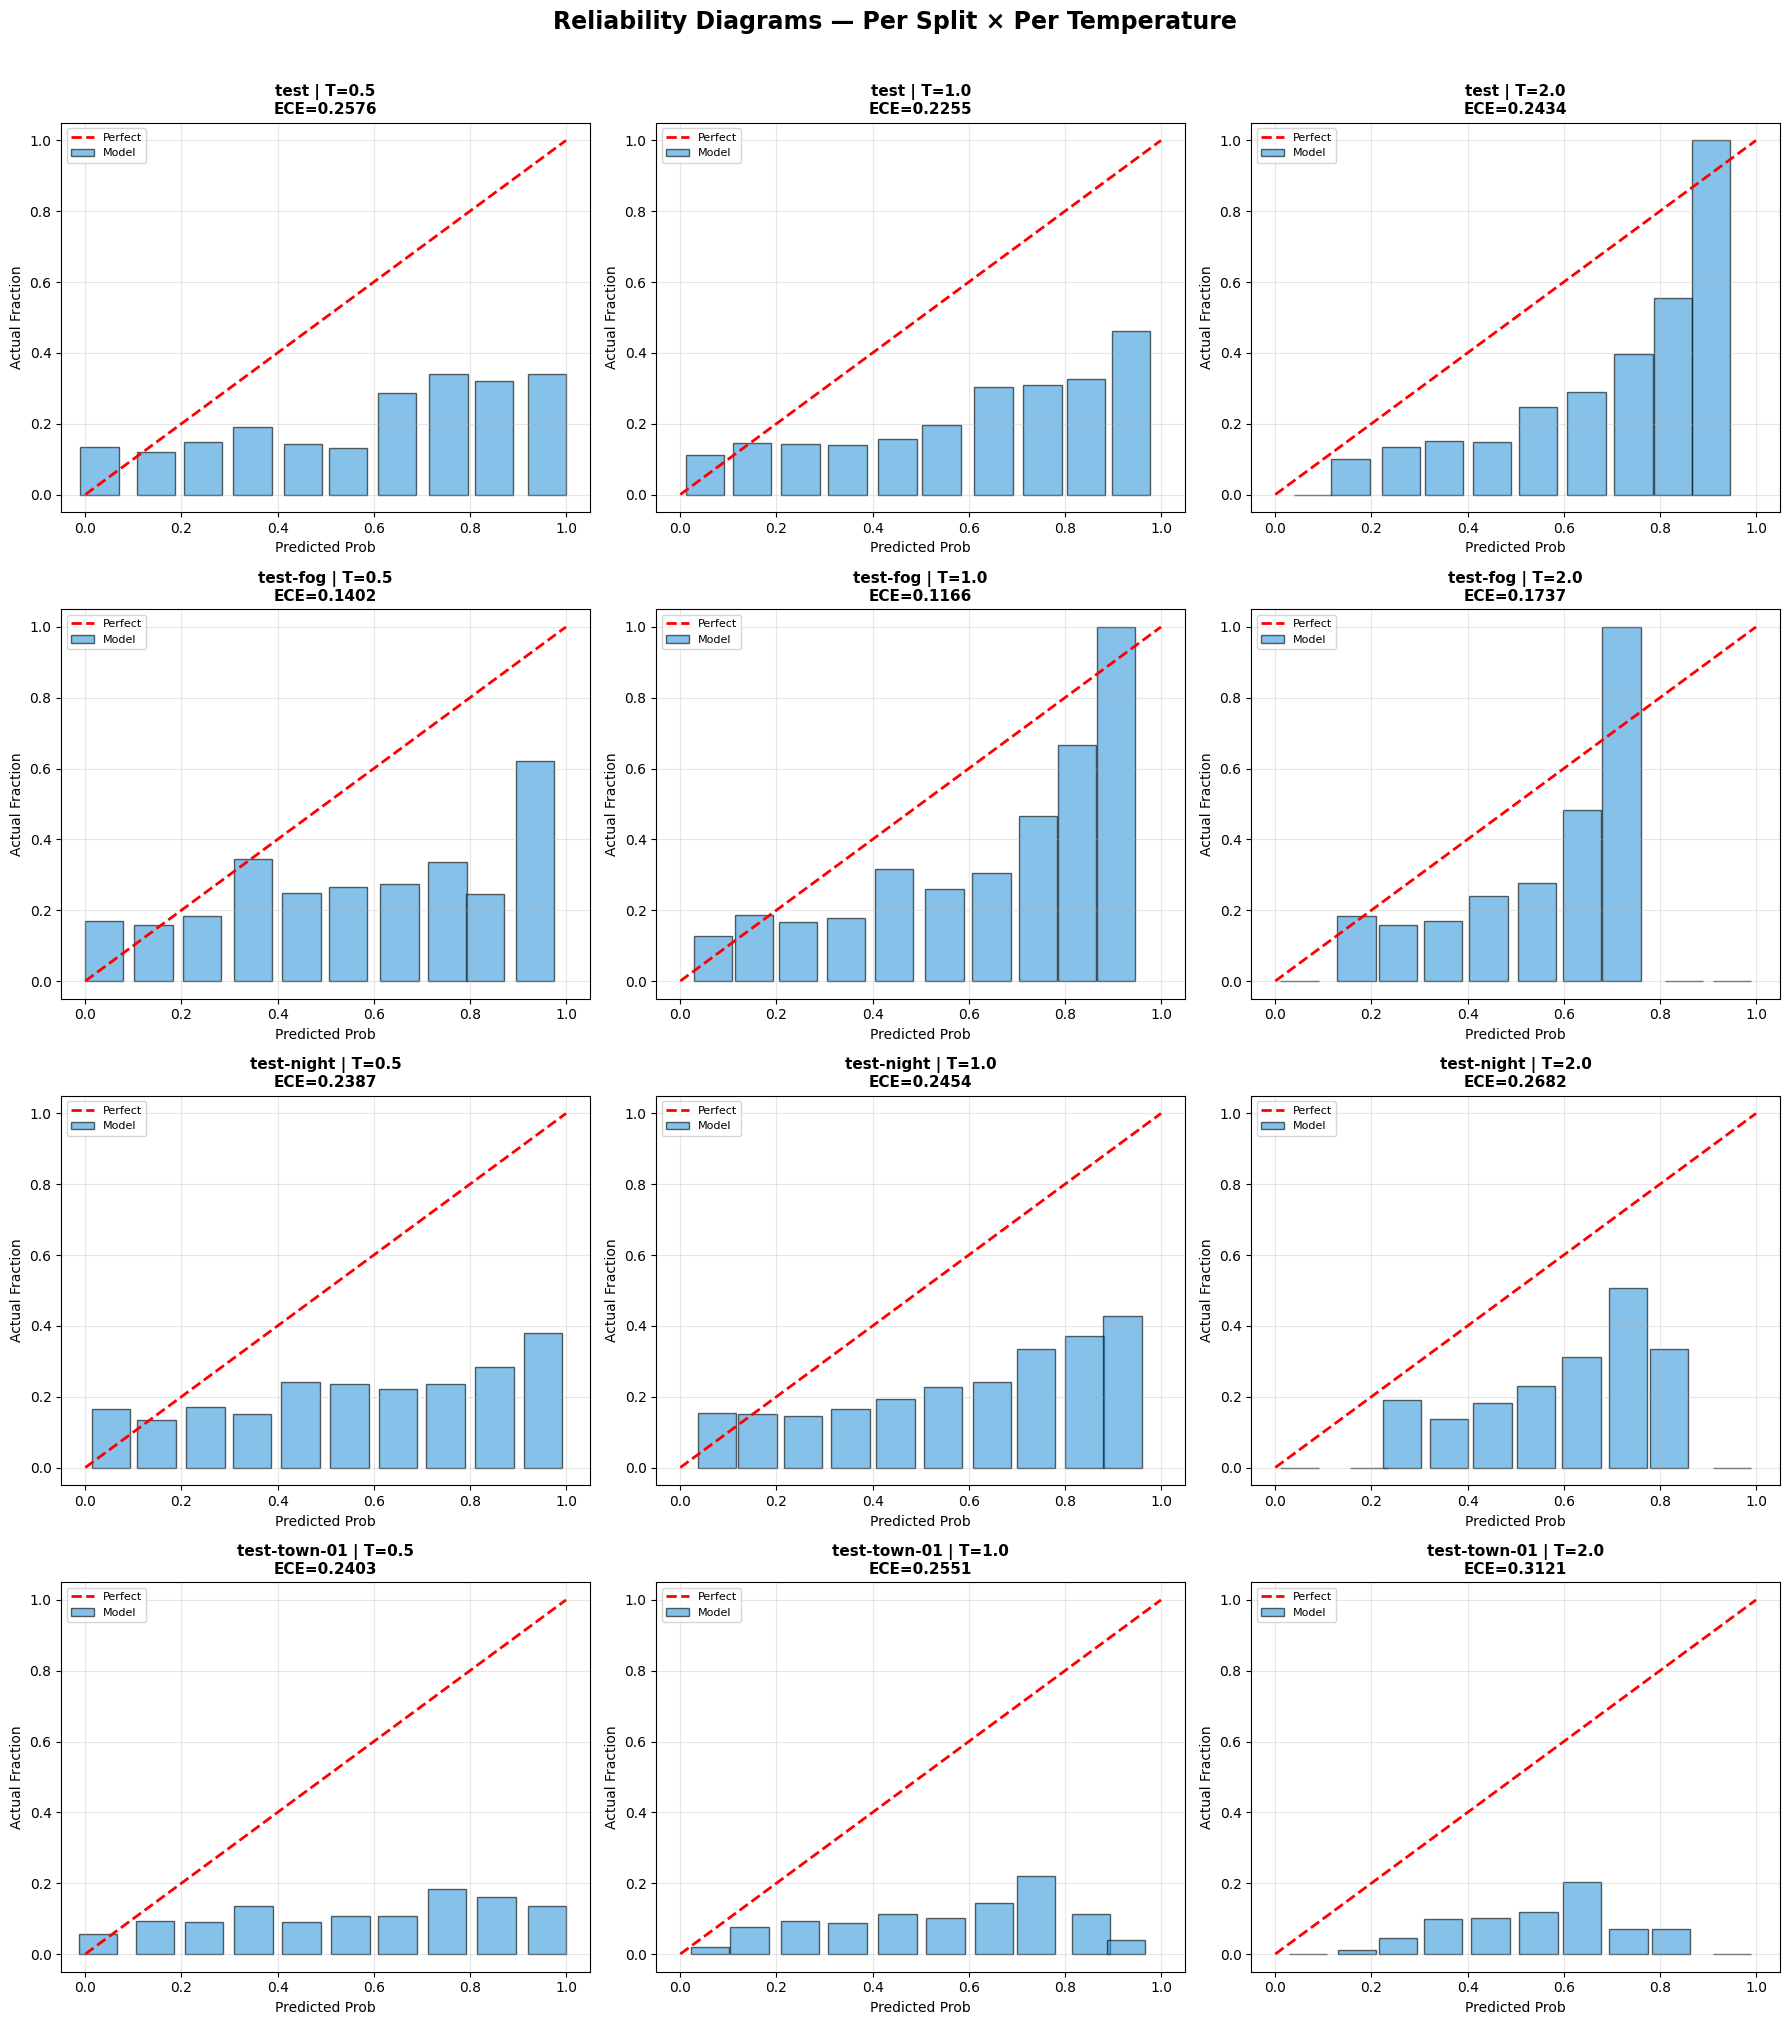

Lower ECE = better calibrated. The temperature that minimizes ECE
gives the most trustworthy confidence scores for the safety constraint.


In [14]:

n_splits = len(split_names)
fig, axes = plt.subplots(n_splits, 3, figsize=(18, 5 * n_splits))
if n_splits == 1:
    axes = [axes]

for row, split_name in enumerate(split_names):
    data = split_data[split_name]
    for col, T in enumerate(temperatures):
        ax = axes[row][col]
        p_T = apply_temperature(data['logits'], T)

        n_bins = 10
        bin_edges = np.linspace(0, 1, n_bins + 1)
        bin_accs, bin_confs, bin_counts = [], [], []

        for i in range(n_bins):
            mask = (p_T >= bin_edges[i]) & (p_T < bin_edges[i+1])
            if mask.sum() > 0:
                bin_accs.append(data['labels'][mask].mean())
                bin_confs.append(p_T[mask].mean())
                bin_counts.append(mask.sum())
            else:
                bin_accs.append(0)
                bin_confs.append((bin_edges[i] + bin_edges[i+1]) / 2)
                bin_counts.append(0)

        bin_accs = np.array(bin_accs)
        bin_confs = np.array(bin_confs)
        total = len(p_T)
        ece = sum(abs(bin_accs[i] - bin_confs[i]) * bin_counts[i] / total
                  for i in range(n_bins))

        ax.bar(bin_confs, bin_accs, width=0.08, alpha=0.6, color='#3498db',
               edgecolor='black', label='Model')
        ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect')
        ax.set_title(f'{split_name} | T={T}\nECE={ece:.4f}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicted Prob', fontsize=10)
        ax.set_ylabel('Actual Fraction', fontsize=10)
        ax.legend(fontsize=8)
        ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)

plt.suptitle('Reliability Diagrams — Per Split × Per Temperature',
             fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/reliability_diagrams_all.png", dpi=150, bbox_inches='tight')
plt.show()

print("Lower ECE = better calibrated. The temperature that minimizes ECE")
print("gives the most trustworthy confidence scores for the safety constraint.")
